In [148]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from data_processing_utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [231]:
# DOUBLE CHECK NO TWO SENSORS IN SAME SEGMENT
speed_data = pd.read_csv("I_35W_data_raw/speedavg_SB.csv").to_numpy() * 1.60934  # convert to kph
flow_data = pd.read_csv("I_35W_data_raw/VOLavg_SB.csv").to_numpy()
print(speed_data.shape)

(73, 1441)


In [232]:
lanes_sb = pd.read_csv("I_35W_data_raw/normalized_lanes_rcs_southbound.csv")["lanes"].to_numpy().flatten()
lanes_sb = np.flip(lanes_sb)

print(lanes_sb.shape)
print(lanes_sb)

(75,)
[2.13954041 2.         2.55997081 2.28668678 1.         1.
 1.98972956 2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.33991119 2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.08870765 1.57012327 2.         2.         2.
 2.35169799 2.         2.         2.         2.         2.38887432
 2.27279252 2.         2.         2.25874473 2.05282146 2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.5770535  2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         1.82967779 1.         1.
 3.48702284 4.37958768 4.        ]


In [233]:
data_freq = 60 # in seconds
metanet_time_step = 10

In [234]:
speed_data_full = np.flip(speed_data, axis=0)
flow_data_full = np.flip(flow_data, axis=0)
speed_data_full = np.repeat(speed_data_full, int(data_freq/metanet_time_step), axis = 1).T
flow_data_full = np.repeat(flow_data_full, int(data_freq/metanet_time_step), axis = 1).T

In [235]:
speed_data_full = np.where(speed_data_full <= 1e-3, 1e-3, speed_data_full)  # to avoid division by zero
flow_data_full = np.where(flow_data_full <= 1e-3, 1e-3, flow_data_full)  # to avoid division by zero
density_data_full = flow_data_full/speed_data_full


In [236]:
print(speed_data_full.shape)

(8646, 73)


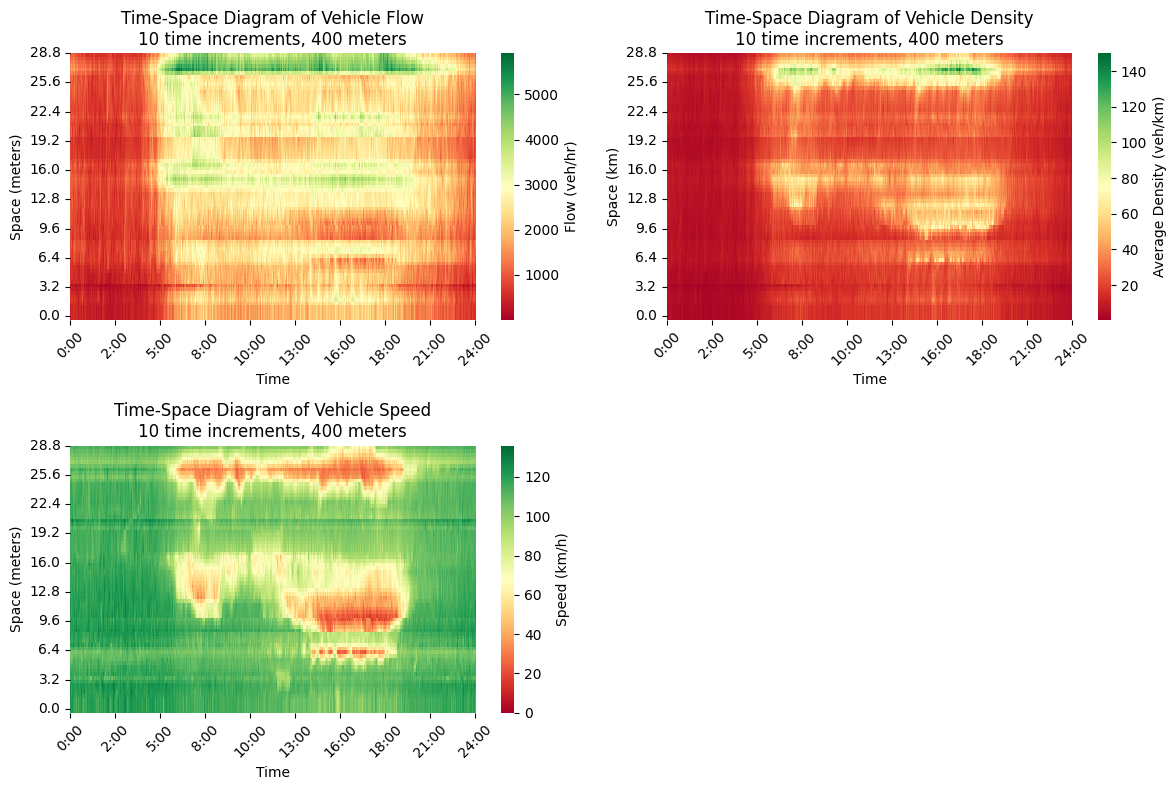

In [237]:
plot_matrices(
    np.flip(flow_data_full, axis=1),
    np.flip(density_data_full, axis=1),
    10,
    400,
    0,
    100,
    0,
    100,
)

In [238]:
# Get data on 2nd half of freeway from 4 pm to 6 pm
## SOUTHBOUND
# seg_start = int(9.6* 1000/400)  # 9.6 km mark
# seg_end = int(18 * 1000/400)  # 16 km mark

# print(seg_start, seg_end)

# time_start = int(6* 3600 / metanet_time_step)
# time_end = int(9.5 * 3600 / metanet_time_step)

## SOUTHBOUND 2
seg_start = int(8* 1000/400)  # 9.6 km mark
seg_end = int(18 * 1000/400)  # 16 km mark

print(seg_start, seg_end)

time_start = int(12* 3600 / metanet_time_step)
time_end = int(20 * 3600 / metanet_time_step)

# ##NORTHBOUND
# seg_start = int(10* 1000/400)  # 9.6 km mark
# seg_end = int(18 * 1000/400)  # 16 km mark

# print(seg_start, seg_end)

# time_start = int(5* 3600 / metanet_time_step)
# time_end = int(9 * 3600 / metanet_time_step)

speed_data_short = speed_data_full[time_start:time_end, seg_start:seg_end]
flow_data_short = flow_data_full[time_start:time_end, seg_start:seg_end]
density_data_short = density_data_full[time_start:time_end, seg_start:seg_end]

20 45


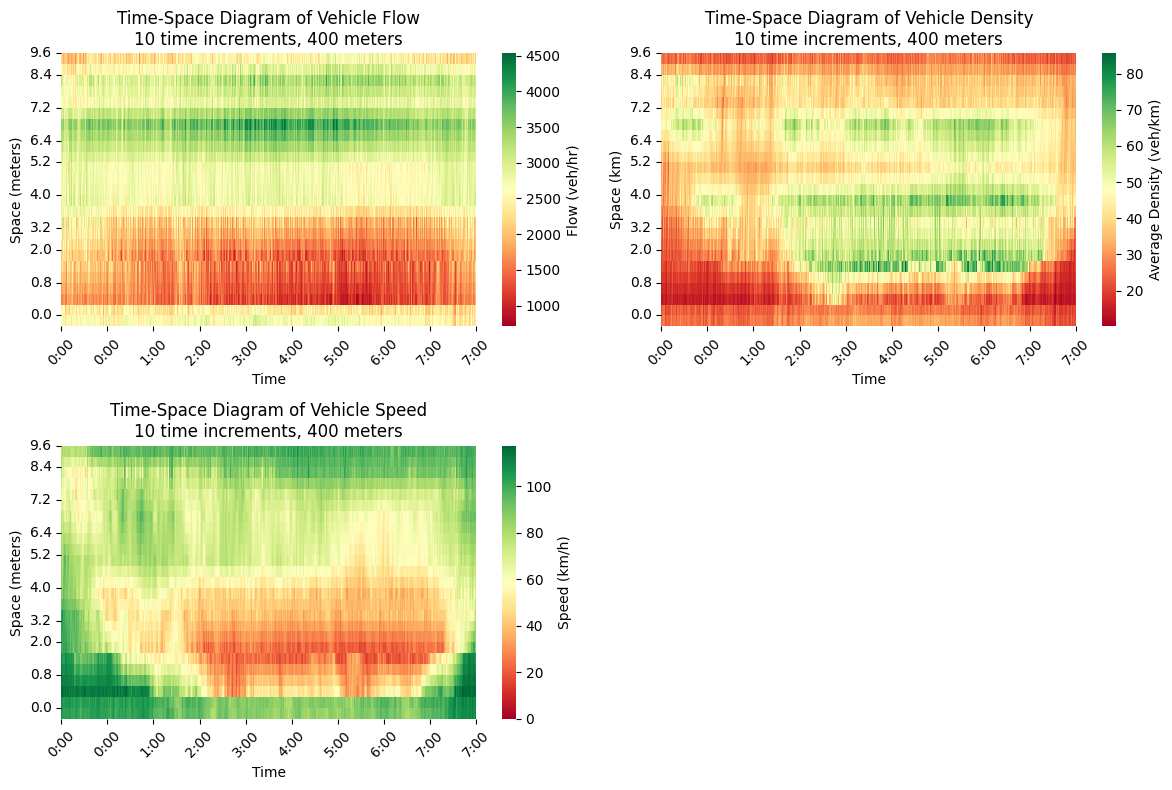

In [239]:
plot_matrices(
    np.flip(flow_data_short, axis=1),
    np.flip(density_data_short, axis=1),
    10,
    400,
    0,
    100,
    0,
    100,
)